## Ques 1.1

In [1]:
import torch
import torch.nn as nn

# Sampling Layer
class Reparameterize(nn.Module):

    def forward(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * log_var)   #σ = exp(0.5 · log σ²)
            eps = torch.randn_like(std)       #ε ~ N(0,I)
            return mu + std * eps             #z = μ+σ·ε
        else:
            return mu                         #deterministic at inference


# Encoder with two parallel heads
class Encoder(nn.Module):

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

        self.fc_mu     = nn.Linear(hidden_dim // 2, latent_dim)  # Mean head
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)  # Log-Variance head

        self.reparameterize = Reparameterize()

    def forward(self, x: torch.Tensor):
        x_flat  = x.view(x.size(0), -1)
        h       = self.shared(x_flat)
        mu      = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        z       = self.reparameterize(mu, log_var)
        return z, mu, log_var

## Ques 1.2

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [5]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    x = x.view(-1, 784)

    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kld_loss

    return total_loss, recon_loss, kld_loss

In [13]:
def train_vae(beta, epochs=20):
    model = VAE(latent_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    total_losses = []
    recon_losses = []
    kld_losses = []

    for epoch in range(epochs):
        model.train()

        total_epoch = 0
        recon_epoch = 0
        kld_epoch = 0
        num_samples = 0   # count images

        for data, _ in train_loader:
            data = data.to(device)
            batch_size = data.size(0)

            optimizer.zero_grad()

            recon, mu, logvar = model(data)
            loss, recon_loss, kld_loss = vae_loss(recon, data, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            # accumulate
            total_epoch += loss.item()
            recon_epoch += recon_loss.item()
            kld_epoch += kld_loss.item()
            num_samples += batch_size

        # normalize per image
        total_epoch /= num_samples
        recon_epoch /= num_samples
        kld_epoch /= num_samples

        total_losses.append(total_epoch)
        recon_losses.append(recon_epoch)
        kld_losses.append(kld_epoch)

        print(f"Beta {beta} | Epoch {epoch+1} | Total={total_epoch:.4f}, Recon={recon_epoch:.4f}, KLD={kld_epoch:.4f}")

    return model, total_losses, recon_losses, kld_losses

In [14]:
betas = [0.1, 1, 5]

models = {}
loss_history = {}

for beta in betas:
    print(f"\nTraining with beta = {beta}")
    model, total, recon, kld = train_vae(beta, epochs=20)

    models[beta] = model
    loss_history[beta] = {
        "total": total,
        "recon": recon,
        "kld": kld
    }


Training with beta = 0.1
Beta 0.1 | Epoch 1 | Total=184.3880, Recon=183.0167, KLD=13.7127
Beta 0.1 | Epoch 2 | Total=162.8746, Recon=161.6675, KLD=12.0719
Beta 0.1 | Epoch 3 | Total=157.7462, Recon=156.5851, KLD=11.6108
Beta 0.1 | Epoch 4 | Total=154.6123, Recon=153.4527, KLD=11.5961
Beta 0.1 | Epoch 5 | Total=152.6354, Recon=151.4787, KLD=11.5668
Beta 0.1 | Epoch 6 | Total=151.2115, Recon=150.0559, KLD=11.5557
Beta 0.1 | Epoch 7 | Total=150.1382, Recon=148.9977, KLD=11.4050
Beta 0.1 | Epoch 8 | Total=149.1858, Recon=148.0500, KLD=11.3579
Beta 0.1 | Epoch 9 | Total=148.3661, Recon=147.2360, KLD=11.3016
Beta 0.1 | Epoch 10 | Total=147.6273, Recon=146.5020, KLD=11.2528
Beta 0.1 | Epoch 11 | Total=147.0663, Recon=145.9409, KLD=11.2547
Beta 0.1 | Epoch 12 | Total=146.4833, Recon=145.3626, KLD=11.2078
Beta 0.1 | Epoch 13 | Total=145.9448, Recon=144.8208, KLD=11.2394
Beta 0.1 | Epoch 14 | Total=145.5617, Recon=144.4390, KLD=11.2274
Beta 0.1 | Epoch 15 | Total=145.1164, Recon=143.9934, KLD=1

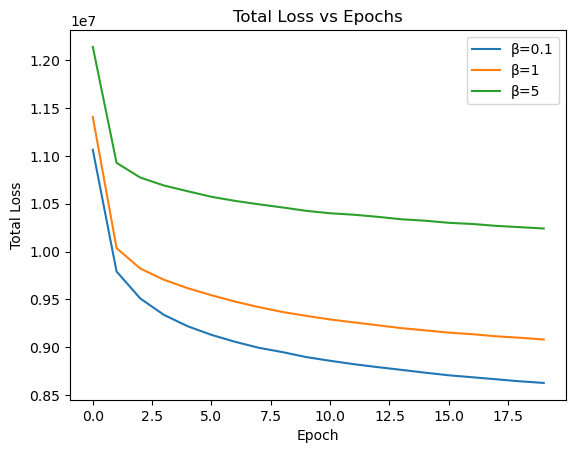

In [8]:
plt.figure()
for beta in betas:
    plt.plot(loss_history[beta]["total"], label=f"β={beta}")

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total Loss vs Epochs")
plt.legend()
plt.show()

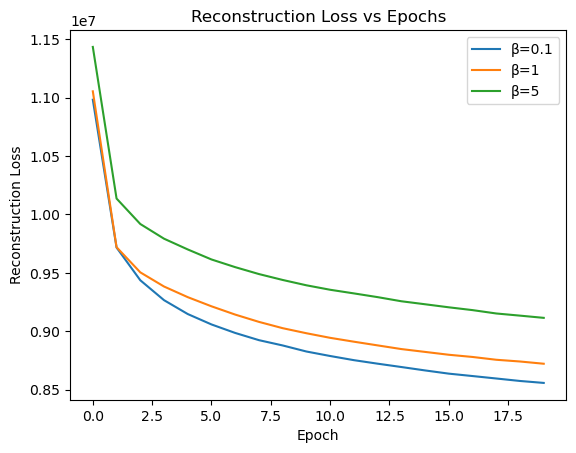

In [9]:
plt.figure()
for beta in betas:
    plt.plot(loss_history[beta]["recon"], label=f"β={beta}")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss vs Epochs")
plt.legend()
plt.show()

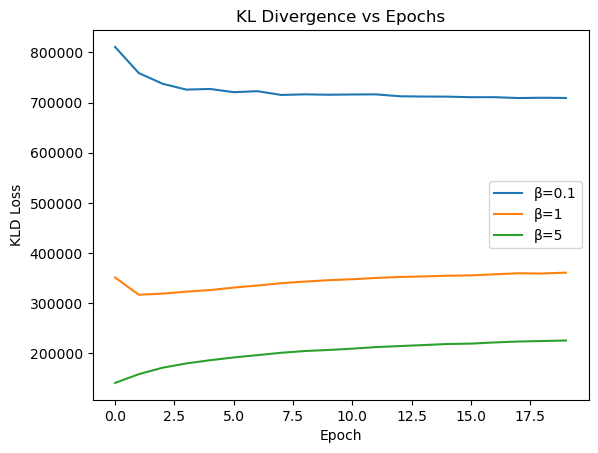

In [10]:
plt.figure()
for beta in betas:
    plt.plot(loss_history[beta]["kld"], label=f"β={beta}")

plt.xlabel("Epoch")
plt.ylabel("KLD Loss")
plt.title("KL Divergence vs Epochs")
plt.legend()
plt.show()

In [11]:
def show_reconstructions(models):
    data, _ = next(iter(train_loader))
    data = data.to(device)

    num_betas = len(models)
    num_images = 8

    plt.figure(figsize=(12, 2 * (num_betas + 1)))

    # ===== ORIGINAL ROW =====
    for i in range(num_images):
        ax = plt.subplot(num_betas + 1, num_images, i + 1)
        ax.imshow(data[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')

        if i == 0:
            ax.set_ylabel("Original", fontsize=12)

    # ===== RECONSTRUCTION ROWS =====
    for row_idx, (beta, model) in enumerate(models.items()):
        model.eval()
        with torch.no_grad():
            recon, _, _ = model(data)
            recon = recon.view(-1, 1, 28, 28)

        for i in range(num_images):
            ax = plt.subplot(num_betas + 1, num_images, (row_idx + 1)*num_images + i + 1)
            ax.imshow(recon[i].cpu().squeeze(), cmap='gray')
            ax.axis('off')

            if i == 0:
                ax.set_ylabel(f"β={beta}", fontsize=12)

    plt.suptitle("Effect of KLD Weight (β) on Reconstruction", fontsize=14)
    plt.tight_layout()
    plt.show()

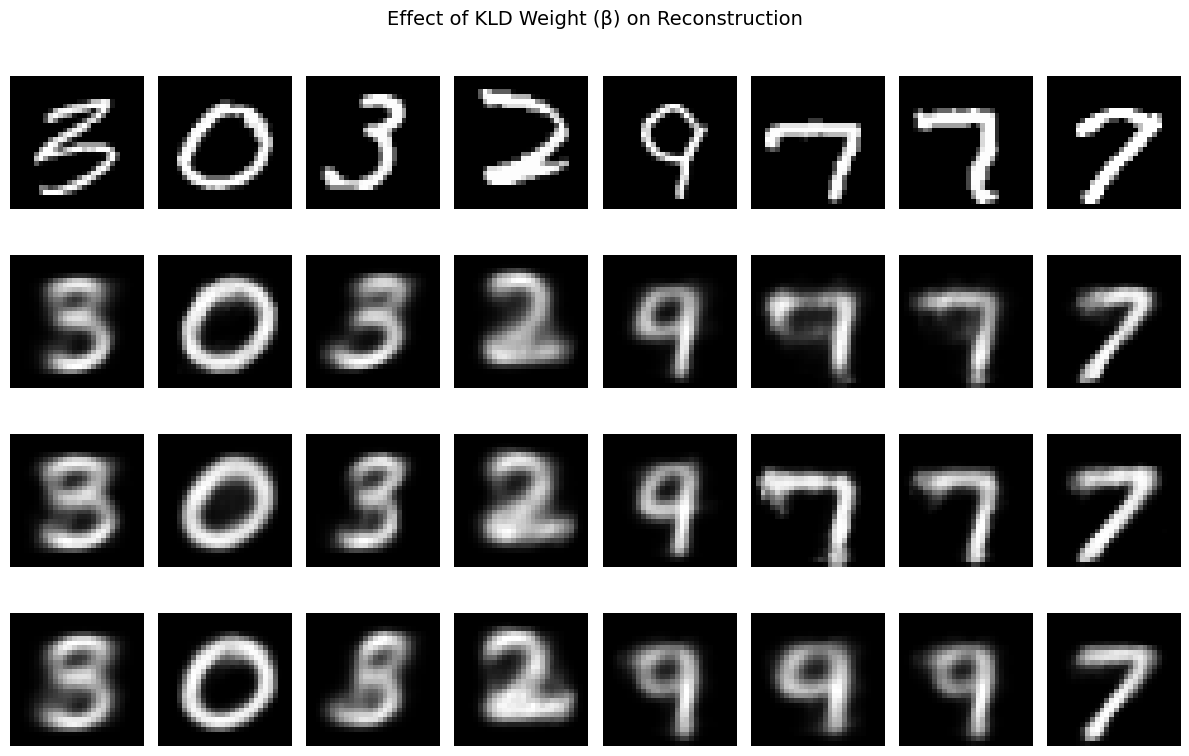

In [12]:
show_reconstructions(models)

## **Part 3: Architecting the Convolutional VAE (CVAE)**

Handling high-dimensional RGB data i.e  Tiny-ImageNet-10

- Input image shape: `64 × 64 × 3`
- Encoder uses `stride = 2` convolutions for downsampling
- Latent representation shape: `1 × 1 × latent_dim`
- Decoder uses `ConvTranspose2d` for upsampling
- Final activation: `Sigmoid`
- Output reconstruction shape: `64 × 64 × 3`

In [6]:
#Imports & Data loading
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

train_dir = "/content/tiny-imagenet/train"
val_dir   = "/content/tiny-imagenet/val"
test_dir  = "/content/tiny-imagenet/test"

batch_size = 64
latent_dim = 128
epochs = 100
lr = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
print("Classes:", train_ds.classes)

Train: 3500 Val: 500 Test: 1000
Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']


In [7]:
# Convolutional VAE Model Architecture
class CVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU(inplace=True)
        )
        self.mu_layer = nn.Conv2d(512, latent_dim, 4, 2, 1)
        self.logvar_layer = nn.Conv2d(512, latent_dim, 4, 2, 1)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

cvae = CVAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(cvae.parameters(), lr=lr)

x, _ = next(iter(train_loader))
x = x[:1].to(device)

with torch.no_grad():
    h = cvae.encoder(x)
    mu = cvae.mu_layer(h)
    logvar = cvae.logvar_layer(h)
    z = cvae.reparameterize(mu, logvar)
    recon = cvae.decoder(z)

print("Input:", x.shape)
print("Encoder output:", h.shape)
print("Mu:", mu.shape)
print("LogVar:", logvar.shape)
print("Latent z:", z.shape)
print("Reconstruction:", recon.shape)

Input: torch.Size([1, 3, 64, 64])
Encoder output: torch.Size([1, 512, 2, 2])
Mu: torch.Size([1, 128, 1, 1])
LogVar: torch.Size([1, 128, 1, 1])
Latent z: torch.Size([1, 128, 1, 1])
Reconstruction: torch.Size([1, 3, 64, 64])


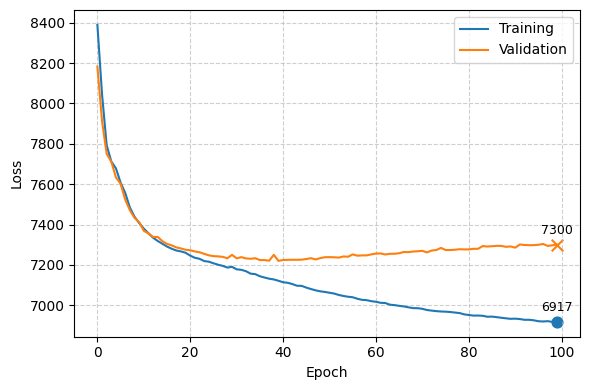

In [8]:
#CVAE is trained using reconstruction loss and KL divergence.
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + kld) / x.size(0)

train_losses = []
val_losses = []

for epoch in range(epochs):
    cvae.train()
    train_total = 0.0
    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad()
        recon, mu, logvar = cvae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        train_total += loss.item() * x.size(0)

    cvae.eval()
    val_total = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device, non_blocking=True)
            recon, mu, logvar = cvae(x)
            loss = vae_loss(recon, x, mu, logvar)
            val_total += loss.item() * x.size(0)

    train_epoch_loss = train_total / len(train_loader.dataset)
    val_epoch_loss = val_total / len(val_loader.dataset)
    train_losses.append(train_epoch_loss)
    val_losses.append(val_epoch_loss)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")

last_epoch = len(train_losses) - 1
plt.scatter(last_epoch, train_losses[-1], marker="o", s=60)
plt.scatter(last_epoch, val_losses[-1], marker="x", s=70)

plt.text(last_epoch, train_losses[-1] + 40, f"{train_losses[-1]:.0f}", ha="center", va="bottom", fontsize=9)
plt.text(last_epoch, val_losses[-1] + 40, f"{val_losses[-1]:.0f}", ha="center", va="bottom", fontsize=9)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, which="both", axis="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

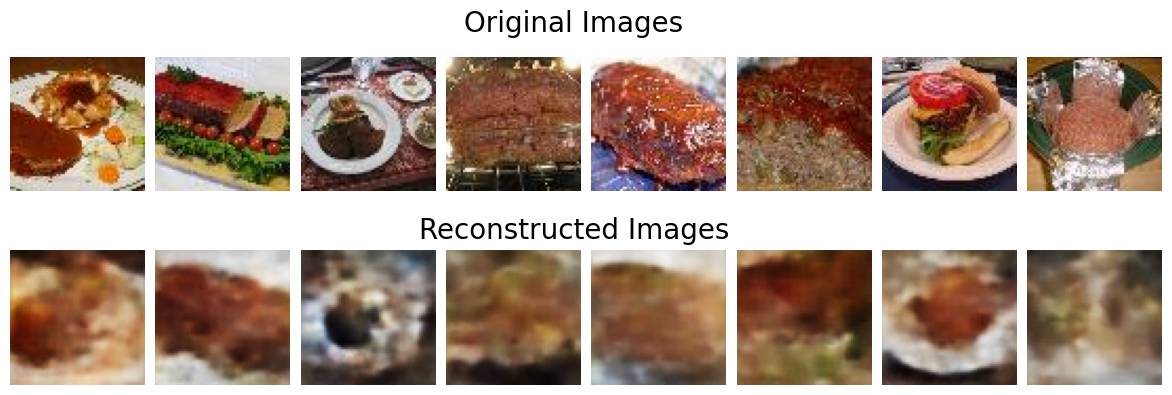

In [9]:
# Reconstruction Visualization on Test Data
cvae.eval()
x, _ = next(iter(test_loader))
x = x[:8].to(device)

with torch.no_grad():
    recon, _, _ = cvae(x)

x = x.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 4.4))

fig.text(0.5, 0.97, "Original Images", ha="center", va="top", fontsize=20)
fig.text(0.5, 0.50, "Reconstructed Images", ha="center", va="top", fontsize=20)

for i in range(8):
    axes[0, i].imshow(x[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")

plt.subplots_adjust(top=0.90, bottom=0.08, left=0.03, right=0.99, hspace=0.16, wspace=0.08)
plt.show()

##part 2.1

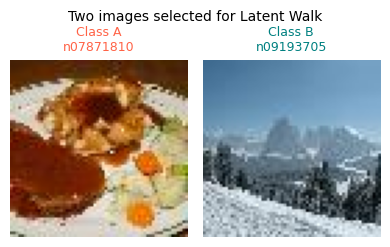

In [10]:
import numpy as np

def get_one_sample_per_class(loader, class_a, class_b, device):
    sample_a, sample_b = None, None
    for images, labels in loader:
        for img, label in zip(images, labels):
            lbl = label.item()
            if lbl == class_a and sample_a is None:
                sample_a = img.unsqueeze(0).to(device)
            if lbl == class_b and sample_b is None:
                sample_b = img.unsqueeze(0).to(device)
            if sample_a is not None and sample_b is not None:
                return sample_a, sample_b

img_a, img_b = get_one_sample_per_class(test_loader, class_a=0, class_b=4, device=device)

# show the two chosen images
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5))
fig.suptitle("Two images selected for Latent Walk", fontsize=10)
axes[0].imshow(img_a.squeeze(0).permute(1,2,0).cpu().numpy())
axes[0].set_title(f'Class A\n{test_ds.classes[0]}', fontsize=9, color='tomato')
axes[0].axis('off')
axes[1].imshow(img_b.squeeze(0).permute(1,2,0).cpu().numpy())
axes[1].set_title(f'Class B\n{test_ds.classes[4]}', fontsize=9, color='teal')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [13]:
cvae.eval()

with torch.no_grad():
    h_a  = cvae.encoder(img_a)
    mu_a = cvae.mu_layer(h_a)      # (1, 128, 1, 1)

    h_b  = cvae.encoder(img_b)
    mu_b = cvae.mu_layer(h_b)      # (1, 128, 1, 1)

N_STEPS = 10
alphas = np.linspace(1, 0, N_STEPS)
interpolated_images = []

with torch.no_grad():
    for alpha in alphas:
        z_new = alpha * mu_a + (1 - alpha) * mu_b   # z_new = α·z1 + (1-α)·z2
        recon = cvae.decoder(z_new)                  # (1, 3, 64, 64)
        img_np = recon.squeeze(0).permute(1,2,0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)
        interpolated_images.append(img_np)

print("Interpolation done ✓")

Interpolation done ✓


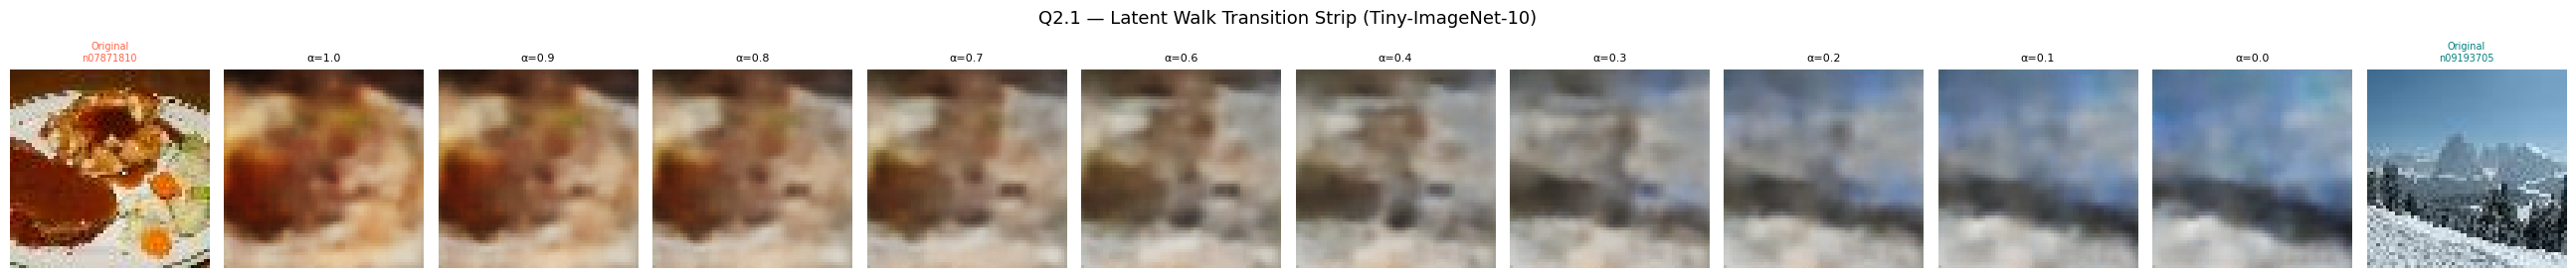

In [14]:
def to_np(tensor):
    return np.clip(tensor.squeeze(0).permute(1,2,0).cpu().numpy(), 0, 1)

fig, axes = plt.subplots(1, N_STEPS + 2, figsize=(26, 3))
fig.suptitle("Q2.1 — Latent Walk Transition Strip (Tiny-ImageNet-10)", fontsize=13)

# original Class A on the left
axes[0].imshow(to_np(img_a))
axes[0].set_title(f'Original\n{test_ds.classes[0]}', fontsize=7, color='tomato')
axes[0].axis('off')

# 10 interpolated frames in the middle
for i, (ax, img) in enumerate(zip(axes[1:-1], interpolated_images)):
    ax.imshow(img)
    ax.set_title(f'α={alphas[i]:.1f}', fontsize=8)
    ax.axis('off')

# original Class B on the right
axes[-1].imshow(to_np(img_b))
axes[-1].set_title(f'Original\n{test_ds.classes[4]}', fontsize=7, color='teal')
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('q2_1_latent_walk.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2

Total images found: 3500


100.0%
100.0%
100.0%
100.0%


Training Tiny-ImageNet...
Epoch 1, Loss: 0.0018
Epoch 2, Loss: 0.0013
Epoch 3, Loss: 0.0011
Epoch 4, Loss: 0.0010
Epoch 5, Loss: 0.0010

Training MNIST...
[MNIST] Epoch 1, Loss: 0.0004
[MNIST] Epoch 2, Loss: 0.0001
[MNIST] Epoch 3, Loss: 0.0001
[MNIST] Epoch 4, Loss: 0.0001
[MNIST] Epoch 5, Loss: 0.0001


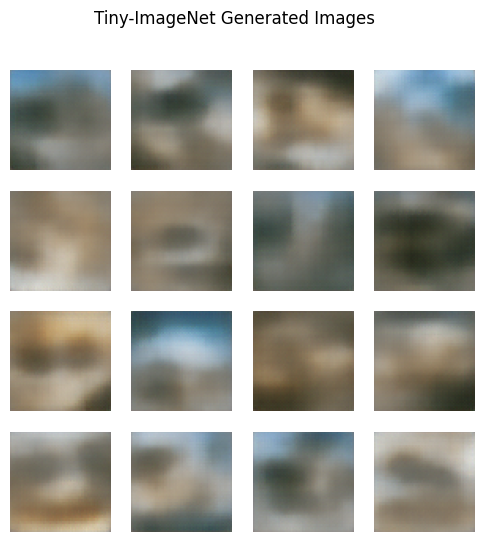

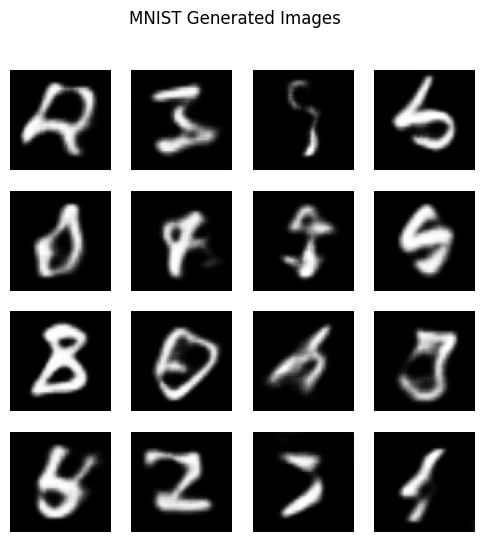

In [1]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --------------------
# FIXED DATASET (only change here)
# --------------------
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []

        # FIX: use os.walk (handles ANY structure)
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith((".jpeg", ".jpg", ".png")):
                    self.image_paths.append(os.path.join(root, file))

        print("Total images found:", len(self.image_paths))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0


# --------------------
# VAE MODEL (same as yours)
# --------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 256*4*4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 256, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# --------------------
# LOSS FUNCTION (FIXED)
# --------------------
def loss_function(recon_x, x, mu, logvar, beta=0.01):  # FIX: smaller beta
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')  # FIX
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())      # FIX
    return recon_loss + beta * kl


# --------------------
# TRANSFORMS (same)
# --------------------
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

mnist_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])


# --------------------
# PATH (your path)
# --------------------
DATA_PATH = r"C:/Users/aashv/Downloads/tiny-imagenet/train"


# --------------------
# LOAD DATA
# --------------------
tiny_dataset = TinyImageNetDataset(DATA_PATH, transform=transform)

if len(tiny_dataset) == 0:
    raise ValueError("Dataset empty — check path")

tiny_loader = DataLoader(tiny_dataset, batch_size=32, shuffle=True)

mnist_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=mnist_transform,
    download=True
)

mnist_loader = DataLoader(mnist_dataset, batch_size=64, shuffle=True)


# --------------------
# DEVICE + MODELS
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(128).to(device)
mnist_model = VAE(128).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=1e-3)


# --------------------
# TRAINING
# --------------------
EPOCHS = 5

print("Training Tiny-ImageNet...")
for epoch in range(EPOCHS):
    total_loss = 0

    for x, _ in tiny_loader:
        x = x.to(device)

        recon, mu, logvar = model(x)
        loss = loss_function(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(tiny_dataset):.4f}")


print("\nTraining MNIST...")
for epoch in range(EPOCHS):
    total_loss = 0

    for x, _ in mnist_loader:
        x = x.to(device)

        recon, mu, logvar = mnist_model(x)
        loss = loss_function(recon, x, mu, logvar)

        mnist_optimizer.zero_grad()
        loss.backward()
        mnist_optimizer.step()

        total_loss += loss.item()

    print(f"[MNIST] Epoch {epoch+1}, Loss: {total_loss/len(mnist_dataset):.4f}")


# --------------------
# GENERATION (PART 2.2)
# --------------------
def generate(model, title):
    model.eval()

    z = torch.randn(16, 128).to(device)

    with torch.no_grad():
        imgs = model.decode(z).cpu()

    fig, axes = plt.subplots(4,4, figsize=(6,6))

    for i, ax in enumerate(axes.flat):
        img = imgs[i].permute(1,2,0)

        if "MNIST" in title:
            img = img.mean(dim=2)
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)

        ax.axis('off')

    plt.suptitle(title)
    plt.show()


generate(model, "Tiny-ImageNet Generated Images")
generate(mnist_model, "MNIST Generated Images")